# Section 1 — Basic Network Traffic Statistics

**Dataset:** 6 CSV files, June 2010 firewall/IDS logs  
**Total flows:** 2,071,657  
**Strategy:** All 6 files combined into a single DataFrame for cross-day analysis.

**Design decisions:**
- Metric for Q1.3: **total bytes** (not flow count) — bytes captures bandwidth impact better
- Time window for Q1.6: **1 hour** — balances granularity vs noise, standard IDS unit
- Spike threshold for Q1.7: **mean + 2σ** — flags statistically extreme values
- Packet size representativeness: checked using **Coefficient of Variation (CV)**

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# loading all csv files and combining them
csv_files = sorted(glob.glob('b/*.csv'))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# converting timestamps
df['startDateTime'] = pd.to_datetime(df['startDateTime'], errors='coerce')
df['stopDateTime'] = pd.to_datetime(df['stopDateTime'], errors='coerce')

print(f"Loaded {len(csv_files)} files")
print(f"Total rows: {len(df)}")
df.head()

Loaded 6 files
Total rows: 2071657


,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 18:21,Unknown_UDP,16076,0,0,178,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,2010-06-13 23:57:00,2010-06-14 00:11:00,Normal
1,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.2.111,tcp_ip,4435,206.217.198.186,80,2010-06-13 23:58:00,2010-06-14 00:01:00,Normal
2,3/11/2014 18:21,DNS,171,642,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.4.119,udp_ip,4428,192.168.5.122,53,2010-06-13 23:58:00,2010-06-13 23:59:00,Normal
3,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.4.119,tcp_ip,3639,219.94.203.105,80,2010-06-13 23:58:00,2010-06-14 00:00:00,Normal
4,3/11/2014 18:21,HTTPImageTransfer,186,128,2,2,NaN,NaN,NaN,NaN,...,"F,P,A",R,192.168.4.119,tcp_ip,3641,98.137.80.50,80,2010-06-13 23:58:00,2010-06-13 23:59:00,Normal


## 1. Total Number of Network Flows

In [2]:
total_flows = len(df)
print(f"Total number of network flows: {total_flows}")

Total number of network flows: 2071657


## 2. Top-k Most Frequently Used Protocols

k is configurable, using default k=5.

Top 5 most used protocols:
  tcp_ip: 1,644,056 (79.4%)
  udp_ip: 419,246 (20.2%)
  icmp_ip: 8,211 (0.4%)
  igmp: 77 (0.0%)
  ip: 66 (0.0%)


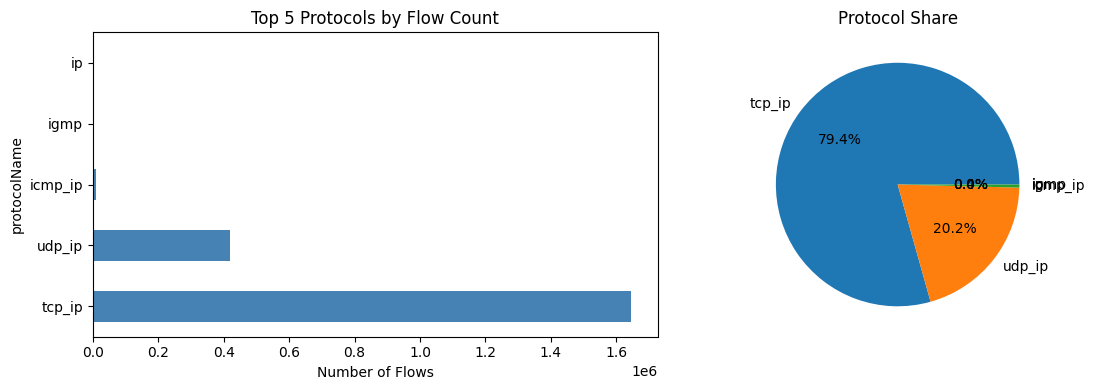

In [3]:
k = 5  # configurable parameter
top_protocols = df['protocolName'].value_counts().head(k)

print(f"Top {k} most used protocols:")
for proto, count in top_protocols.items():
    pct = count / len(df) * 100
    print(f"  {proto}: {count:,} ({pct:.1f}%)")

# visualizing protocol distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
top_protocols.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title(f'Top {k} Protocols by Flow Count')
ax1.set_xlabel('Number of Flows')

top_protocols.plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Protocol Share')
ax2.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Top 10 Most Active Source and Destination IPs

Metric used: **total bytes** (sum of totalSourceBytes / totalDestinationBytes per IP). Bytes captures actual bandwidth impact and traffic volume better than flow count, since a single large transfer matters more than many tiny keep-alive flows.

Top 10 Source IPs (by total bytes sent):
   1. 192.168.2.107            1766.7 MB
   2. 192.168.4.121             348.2 MB
   3. 192.168.2.109             279.6 MB
   4. 192.168.1.105             234.0 MB
   5. 192.168.1.101             229.2 MB
   6. 192.168.2.112             219.6 MB
   7. 192.168.2.113             219.0 MB
   8. 192.168.4.118             201.2 MB
   9. 192.168.1.103             190.9 MB
  10. 192.168.2.110             176.5 MB

Top 10 Destination IPs (by total bytes received):
   1. 192.168.5.122            9583.1 MB
   2. 69.84.133.138            5619.0 MB
   3. 95.154.240.242           3879.5 MB
   4. 68.178.178.97            2801.8 MB
   5. 203.73.24.75             1998.5 MB
   6. 79.125.17.124            1294.9 MB
   7. 68.178.178.33            1222.2 MB
   8. 91.190.170.71            1037.3 MB
   9. 72.32.84.3                784.1 MB
  10. 195.189.143.147           752.3 MB


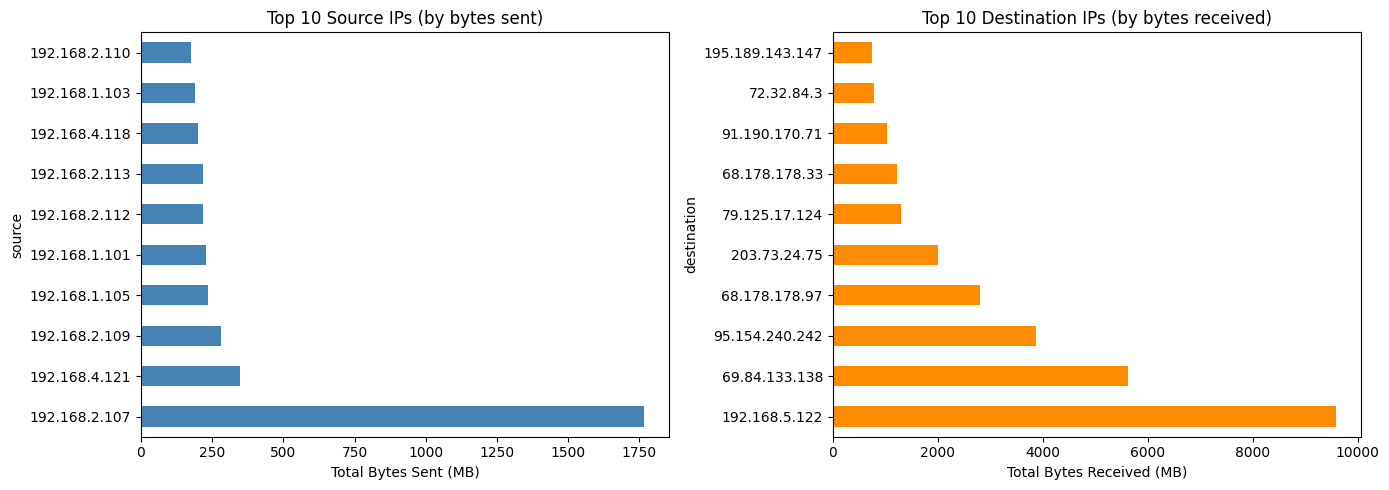

In [4]:
top_src = df.groupby('source')['totalSourceBytes'].sum().sort_values(ascending=False).head(10)
top_dst = df.groupby('destination')['totalDestinationBytes'].sum().sort_values(ascending=False).head(10)

print("Top 10 Source IPs (by total bytes sent):")
for i, (ip, b) in enumerate(top_src.items(), 1):
    print(f"  {i:>2}. {ip:<20} {b/1e6:>10.1f} MB")

print("\nTop 10 Destination IPs (by total bytes received):")
for i, (ip, b) in enumerate(top_dst.items(), 1):
    print(f"  {i:>2}. {ip:<20} {b/1e6:>10.1f} MB")

# bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
(top_src / 1e6).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 10 Source IPs (by bytes sent)')
ax1.set_xlabel('Total Bytes Sent (MB)')
(top_dst / 1e6).plot(kind='barh', ax=ax2, color='darkorange')
ax2.set_title('Top 10 Destination IPs (by bytes received)')
ax2.set_xlabel('Total Bytes Received (MB)')
plt.tight_layout()
plt.show()

## 4. Average Packet Size

Computing the overall average packet size across all flows.

In [5]:
total_bytes = df['totalSourceBytes'].sum() + df['totalDestinationBytes'].sum()
total_packets = df['totalSourcePackets'].sum() + df['totalDestinationPackets'].sum()

avg_pkt_size = total_bytes / total_packets
print(f"Average packet size: {avg_pkt_size:.2f} bytes")

# also computing per-flow stats to check representativeness
df['totalBytes'] = df['totalSourceBytes'] + df['totalDestinationBytes']
mean_bytes = df['totalBytes'].mean()
std_bytes = df['totalBytes'].std()
cv = std_bytes / mean_bytes

print(f"Mean total bytes per flow: {mean_bytes:.2f}")
print(f"Std deviation: {std_bytes:.2f}")
print(f"Coefficient of Variation: {cv:.2f}")
print()
print("The CV is very high (>>1), which means the average is NOT representative.")
print("Flow sizes range from tiny control packets to multi-MB transfers.")
print("Median or percentile-based measures would be more appropriate.")

Average packet size: 736.92 bytes
Mean total bytes per flow: 36950.06
Std deviation: 1446484.82
Coefficient of Variation: 39.15

The CV is very high (>>1), which means the average is NOT representative.
Flow sizes range from tiny control packets to multi-MB transfers.
Median or percentile-based measures would be more appropriate.


## 5. Top 3 Most Frequent Source-Destination Pairs

In [6]:
pair_counts = df.groupby(['source', 'destination']).size().reset_index(name='flows')
pair_counts = pair_counts.sort_values('flows', ascending=False).head(3)

print("Top 3 source-destination pairs:")
for i, (_, row) in enumerate(pair_counts.iterrows(), 1):
    print(f"  {i}. {row['source']} -> {row['destination']}: {row['flows']:,} flows")

Top 3 source-destination pairs:
  1. 192.168.5.122 -> 198.164.30.2: 232,409 flows
  2. 192.168.2.107 -> 125.6.164.51: 58,744 flows
  3. 192.168.3.115 -> 203.73.24.75: 43,785 flows


## 6. Consistently Communicating IPs

**Time window:** 1-hour intervals using `dt.floor('h')` on `startDateTime`.

**Justification:** Hourly windows are fine-grained enough to detect communication gaps while being coarse enough to tolerate brief idle periods. An IP active in >=80% of all hourly windows is considered a consistent communicator.

In [7]:
df['hour_window'] = df['startDateTime'].dt.floor('h')
total_windows = df['hour_window'].nunique()

# count how many windows each source IP appears in
ip_window_counts = df.groupby('source')['hour_window'].nunique()
threshold = int(total_windows * 0.80)

consistent_ips = ip_window_counts[ip_window_counts >= threshold].sort_values(ascending=False)

print(f"Total hourly windows: {total_windows}")
print(f"Threshold (80%): {threshold} windows")
print(f"IPs meeting threshold: {len(consistent_ips)}")
print()
print("Consistently communicating IPs:")
for ip, cnt in consistent_ips.items():
    print(f"  {ip}: active in {cnt}/{total_windows} windows ({cnt/total_windows*100:.1f}%)")

Total hourly windows: 146
Threshold (80%): 116 windows
IPs meeting threshold: 25

Consistently communicating IPs:
  192.168.1.101: active in 145/146 windows (99.3%)
  192.168.2.106: active in 145/146 windows (99.3%)
  192.168.1.102: active in 145/146 windows (99.3%)
  192.168.1.103: active in 145/146 windows (99.3%)
  192.168.1.104: active in 145/146 windows (99.3%)
  192.168.2.107: active in 145/146 windows (99.3%)
  192.168.1.105: active in 145/146 windows (99.3%)
  192.168.2.109: active in 145/146 windows (99.3%)
  192.168.2.108: active in 145/146 windows (99.3%)
  192.168.3.116: active in 145/146 windows (99.3%)
  192.168.4.118: active in 145/146 windows (99.3%)
  192.168.2.110: active in 145/146 windows (99.3%)
  192.168.2.111: active in 145/146 windows (99.3%)
  192.168.2.112: active in 145/146 windows (99.3%)
  192.168.2.113: active in 145/146 windows (99.3%)
  192.168.3.114: active in 145/146 windows (99.3%)
  192.168.3.115: active in 145/146 windows (99.3%)
  192.168.5.122: ac

## 7. Irregular Traffic Spikes

**Method:** Hourly total bytes summed and converted to MB. A spike is any hour where volume exceeds mean + 2*std.

**Possible causes:** Large file transfers, backup jobs, DDoS bursts, software updates.

Mean hourly traffic: 524.30 MB
Std: 767.91 MB
Spike threshold (mean + 2*std): 2060.11 MB
Number of spikes detected: 2

  2010-06-13 10:00:00 -> 2356.77 MB
  2010-06-15 16:00:00 -> 7720.05 MB


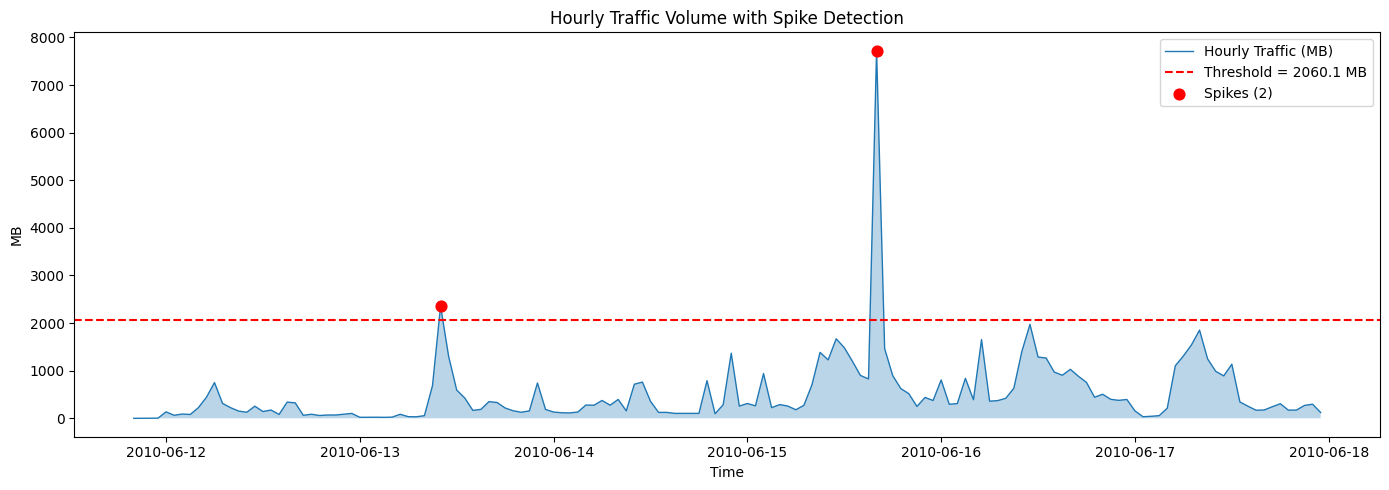

In [8]:
df['total_bytes_flow'] = df['totalSourceBytes'] + df['totalDestinationBytes']
hourly_mb = df.groupby('hour_window')['total_bytes_flow'].sum() / 1e6

mean_mb = hourly_mb.mean()
std_mb = hourly_mb.std()
spike_threshold = mean_mb + 2 * std_mb

spikes = hourly_mb[hourly_mb > spike_threshold]

print(f"Mean hourly traffic: {mean_mb:.2f} MB")
print(f"Std: {std_mb:.2f} MB")
print(f"Spike threshold (mean + 2*std): {spike_threshold:.2f} MB")
print(f"Number of spikes detected: {len(spikes)}")
print()
for time, vol in spikes.items():
    print(f"  {time} -> {vol:.2f} MB")

# plotting
plt.figure(figsize=(14, 5))
plt.fill_between(hourly_mb.index, hourly_mb.values, alpha=0.3)
plt.plot(hourly_mb.index, hourly_mb.values, lw=1, label='Hourly Traffic (MB)')
plt.axhline(spike_threshold, color='red', linestyle='--', lw=1.5, label=f'Threshold = {spike_threshold:.1f} MB')
plt.scatter(spikes.index, spikes.values, color='red', s=60, zorder=5, label=f'Spikes ({len(spikes)})')
plt.title('Hourly Traffic Volume with Spike Detection')
plt.xlabel('Time')
plt.ylabel('MB')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Variance of Packet Sizes

Variance of packet sizes: 2092318321350.68
Std deviation: 1446484.82
Mean: 36950.06

Analysis:
The variance is extremely high, indicating flow sizes vary enormously.
Reasons for high variance:
  1. Mixed traffic types - small ACK packets coexist with large file transfers
  2. Protocol diversity - TCP bulk downloads vs UDP keep-alives
  3. Attack traffic - scanning flows have tiny payloads, DDoS has large volumes
  4. Asymmetric flows - uploads vs downloads have very different sizes


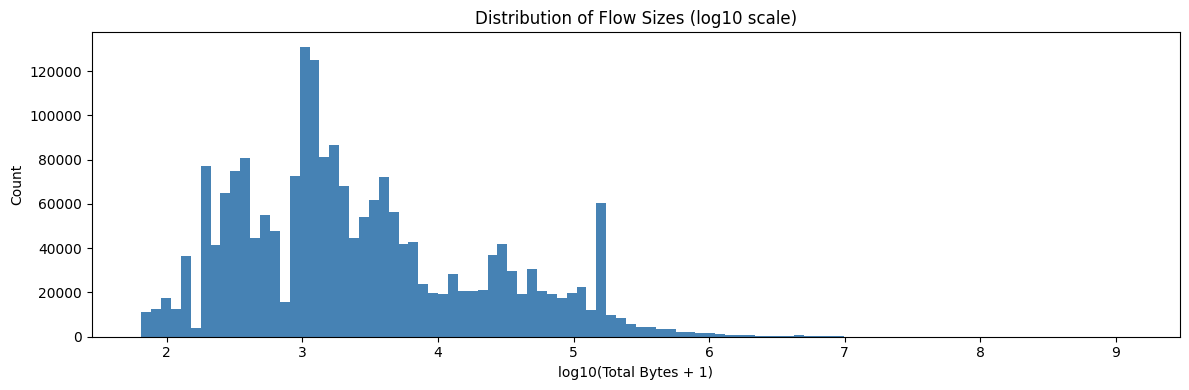

In [9]:
variance = df['totalBytes'].var()
print(f"Variance of packet sizes: {variance:.2f}")
print(f"Std deviation: {df['totalBytes'].std():.2f}")
print(f"Mean: {df['totalBytes'].mean():.2f}")
print()
print("Analysis:")
print("The variance is extremely high, indicating flow sizes vary enormously.")
print("Reasons for high variance:")
print("  1. Mixed traffic types - small ACK packets coexist with large file transfers")
print("  2. Protocol diversity - TCP bulk downloads vs UDP keep-alives")
print("  3. Attack traffic - scanning flows have tiny payloads, DDoS has large volumes")
print("  4. Asymmetric flows - uploads vs downloads have very different sizes")

# histogram
plt.figure(figsize=(12, 4))
positive = df[df['totalBytes'] > 0]['totalBytes']
plt.hist(np.log10(positive + 1), bins=100, color='steelblue', edgecolor='none')
plt.title('Distribution of Flow Sizes (log10 scale)')
plt.xlabel('log10(Total Bytes + 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()